# Predicting Aircraft Engine RUL using NASA CMAPSS (Commericial Modular Aero-Propulsion System Simulation) Dataset using Machine Learning

Make Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Defining column names:

The dataset provided by NASA CMAPSS contains not CSV values or any column headers. Hence, with reference to research paper *Damage Propagation Modeling for Aircraft
Engine Run-to-Failure Simulation*, 21 row headings need to be added according to sensors outputs.

In [26]:
index_names   = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = [
    '(Fan inlet temperature) (◦R)',
    '(LPC outlet temperature) (◦R)',
    '(HPC outlet temperature) (◦R)',
    '(LPT outlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(bypass-duct pressure) (psia)',
    '(HPC outlet pressure) (psia)',
    '(Physical fan speed) (rpm)',
    '(Physical core speed) (rpm)',
    '(Engine pressure ratio(P50/P2)',
    '(HPC outlet Static pressure) (psia)',
    '(Ratio of fuel flow to Ps30) (pps/psia)',
    '(Corrected fan speed) (rpm)',
    '(Corrected core speed) (rpm)',
    '(Bypass Ratio) ',
    '(Burner fuel-air ratio)',
    '(Bleed Enthalpy)',
    '(Required fan speed)',
    '(Required fan conversion speed)',
    '(High-pressure turbines Cool air flow)',
    '(Low-pressure turbines Cool air flow)'
]
col_names = index_names + setting_names + sensor_names

Load Data:

Train Data

In [27]:
dftrain1 = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
dftrain2 = pd.read_csv('train_FD002.txt', sep='\s+', header=None, names=col_names)
dftrain3 = pd.read_csv('train_FD003.txt', sep='\s+', header=None, names=col_names)
dftrain4 = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)

# Make raw copies of each dataframe
raw_dftrain1 = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
raw_dftrain2 = pd.read_csv('train_FD002.txt', sep='\s+', header=None, names=col_names)
raw_dftrain3 = pd.read_csv('train_FD003.txt', sep='\s+', header=None, names=col_names)
raw_dftrain4 = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)

In [28]:
dftrain1.head()

,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),...,(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [29]:
dftrain1.describe()

,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),...,(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


Plotting histograms for each feature to know which will contribute to the model traning.

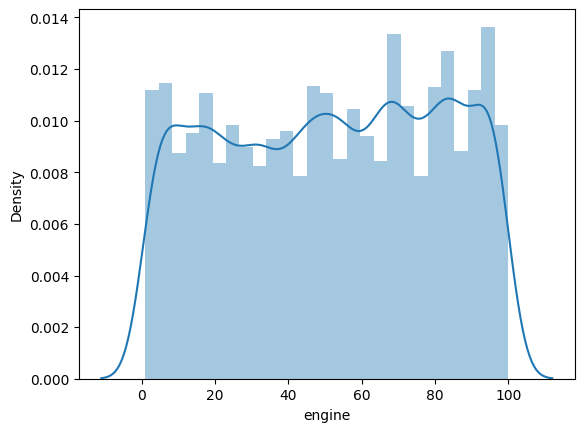

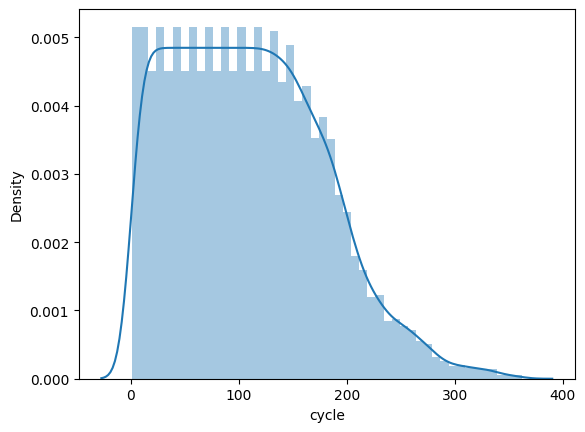

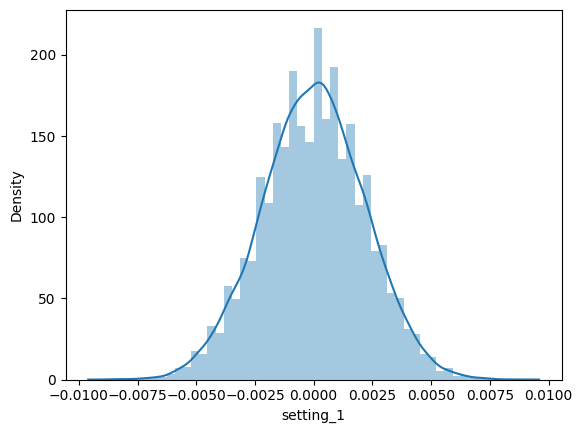

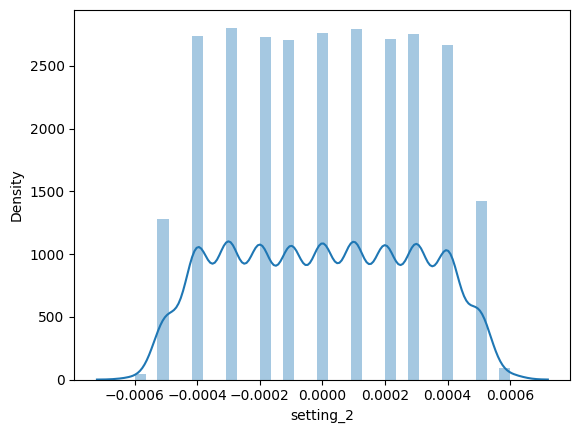

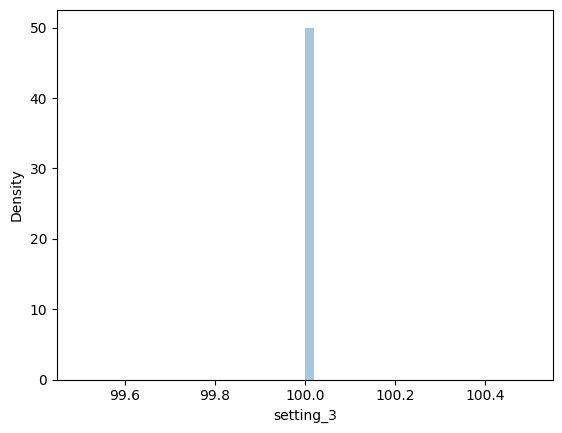

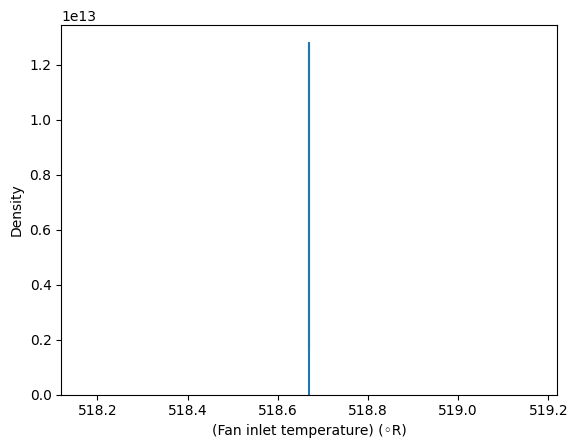

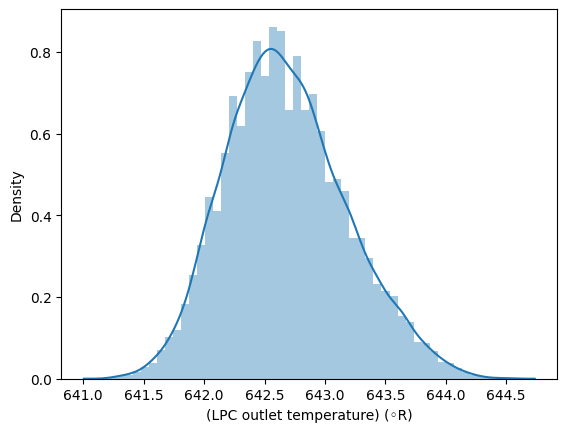

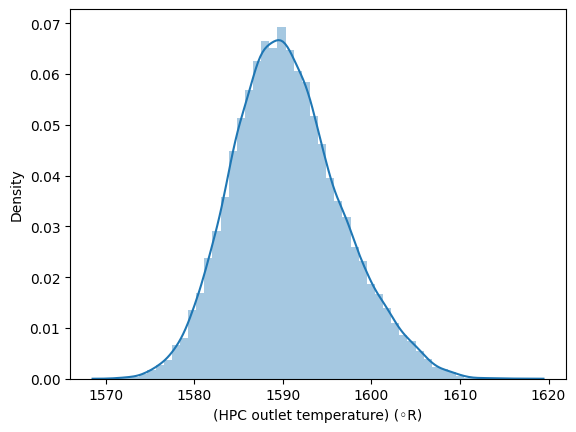

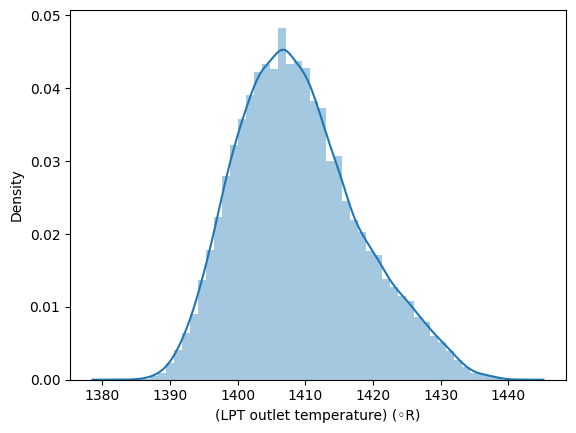

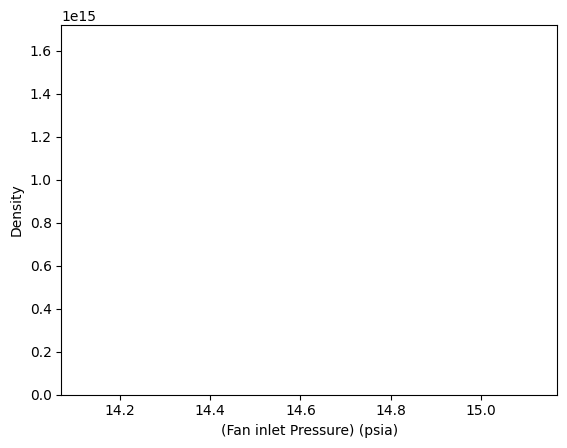

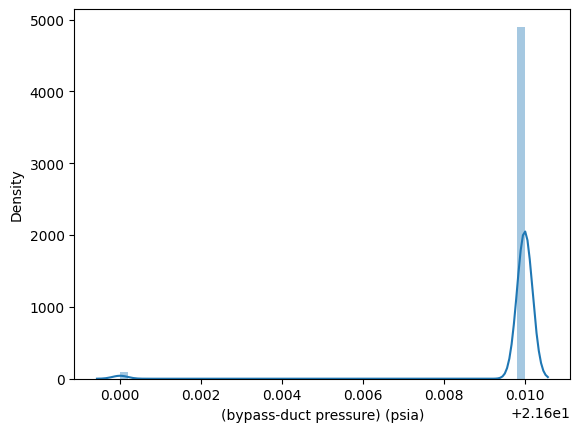

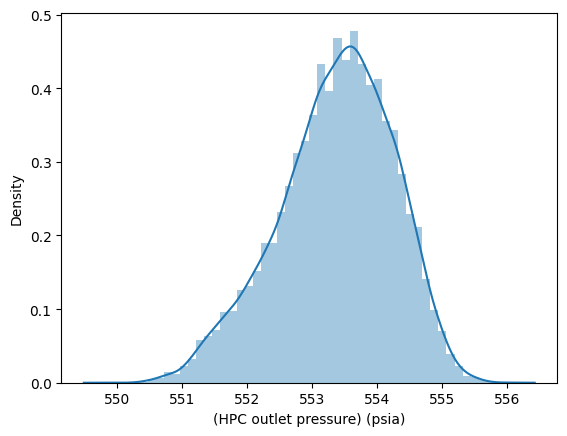

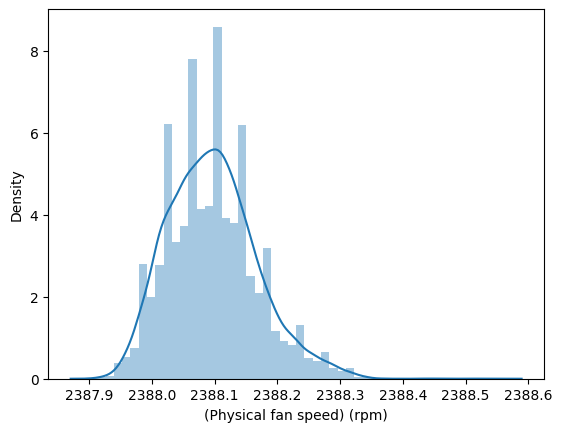

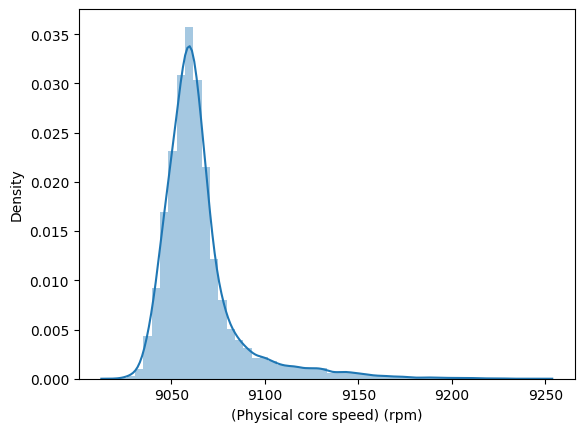

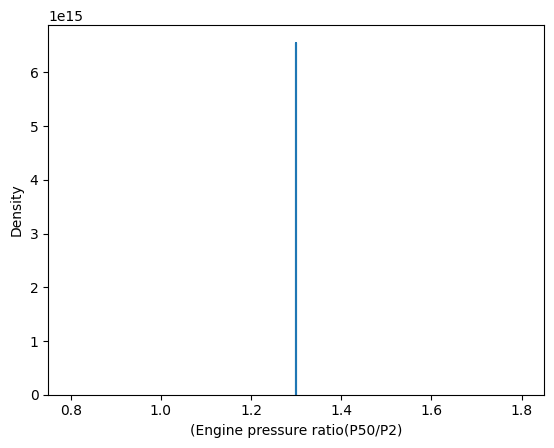

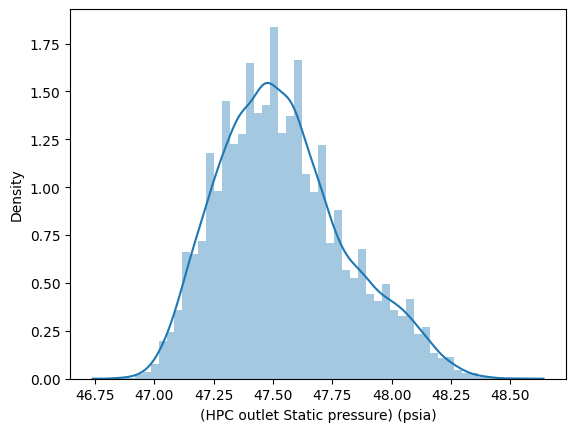

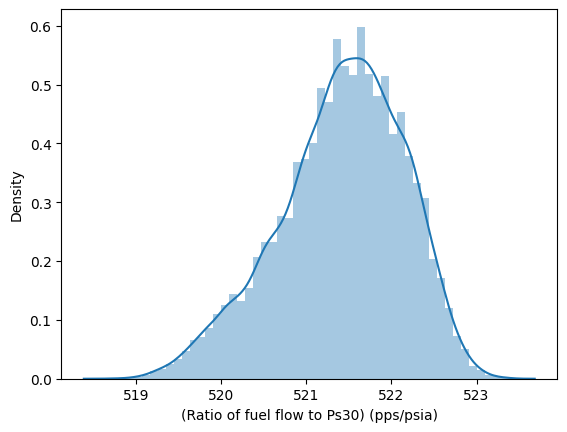

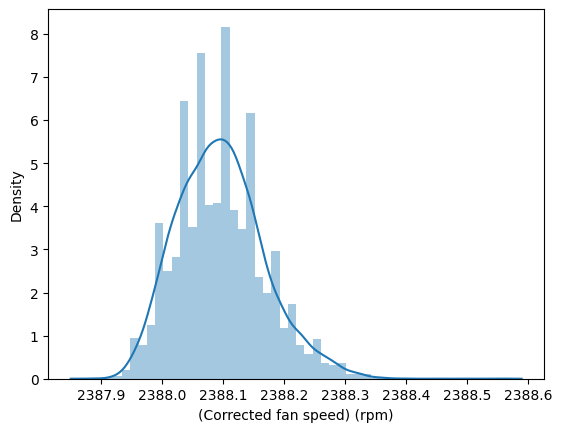

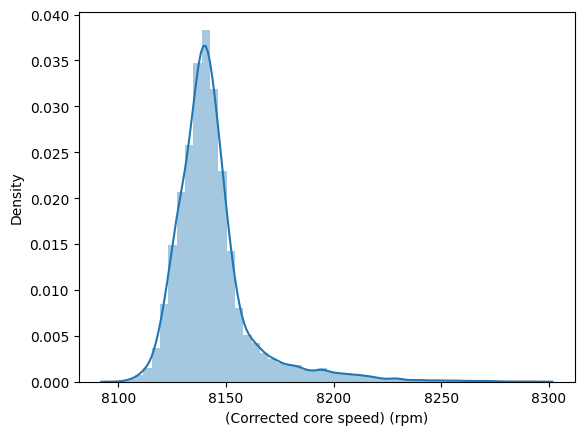

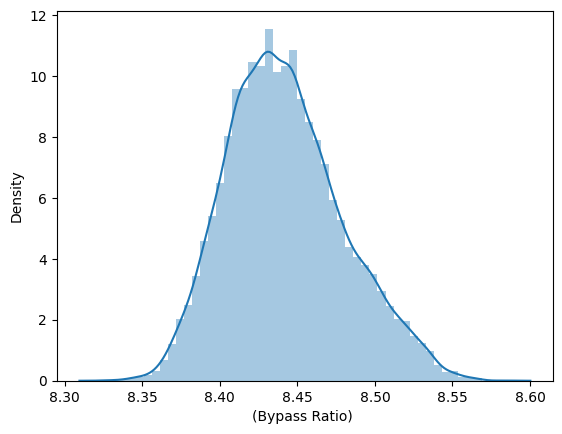

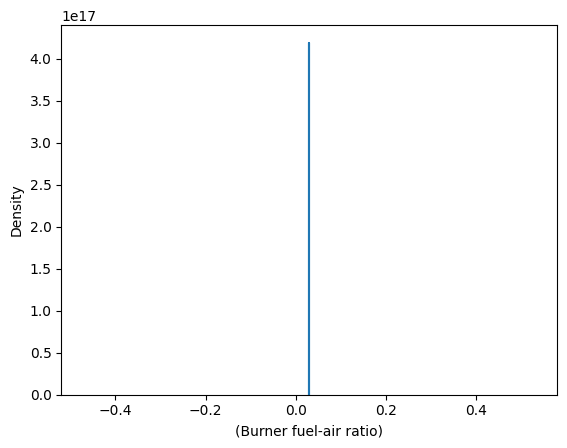

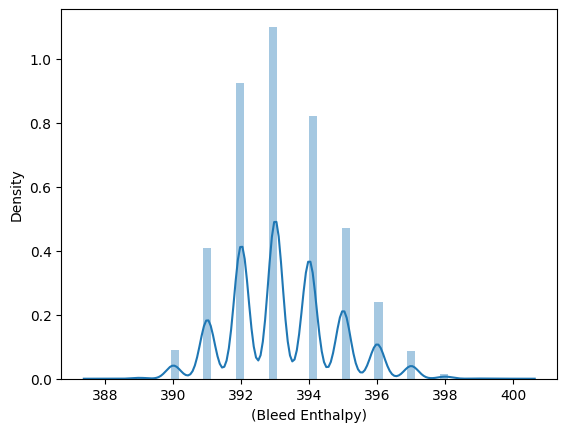

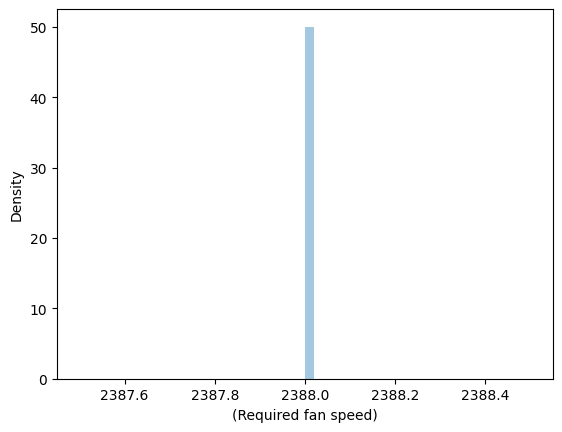

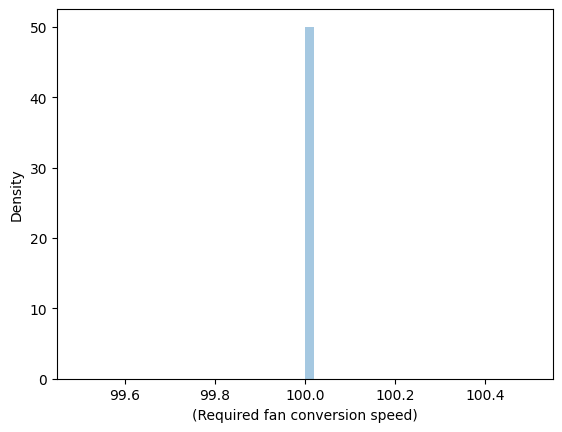

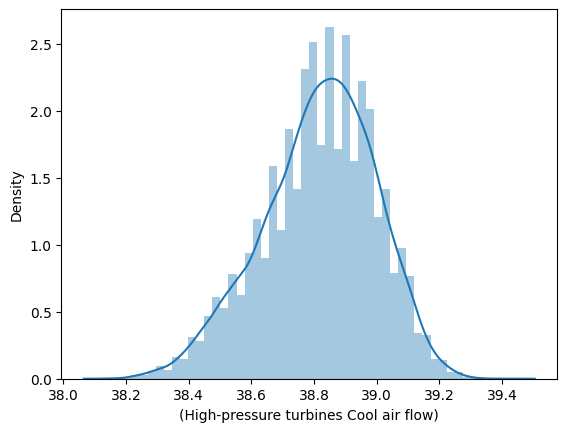

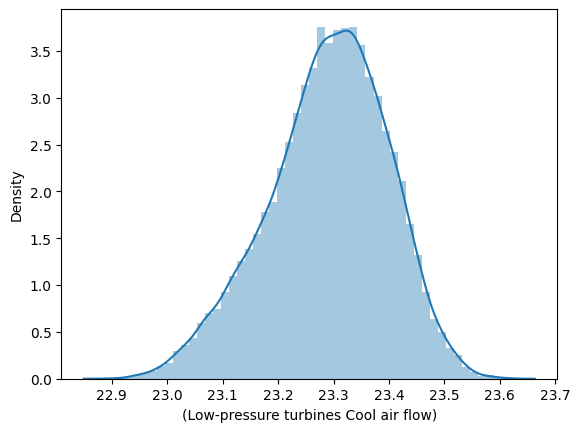

In [30]:
for cols in dftrain1.columns:
    sns.distplot(dftrain1[cols])
    plt.show()

From above, the features identified with strictly zero or negligible standard deviation (effectively constant values) in `dftrain1` are:
- `setting_3`
- `(Fan inlet temperature) (◦R)`
- `(LPC outlet temperature) (◦R)`
- `(Fan inlet Pressure) (psia)`
- `(Engine pressure ratio(P50/P2)`
- `(Burner fuel-air ratio)`
- `(Required fan speed)`
- `(Required fan conversion speed)`


In [31]:
training_dataframes = {'dftrain1': dftrain1, 'dftrain2': dftrain2, 'dftrain3': dftrain3, 'dftrain4': dftrain4}

epsilon = 1e-6 # Define a small epsilon for 'effectively zero' standard deviation

effectively_constant_features_per_df = {}

print("Features with effectively zero standard deviation (std < epsilon) in each training DataFrame:")
for df_name, df in training_dataframes.items():
    # Exclude 'engine' and 'cycle' from this check as they are identifiers
    cols_to_check = [col for col in df.columns if col not in ['engine', 'cycle']]

    effectively_constant_df = [col for col in cols_to_check if df[col].std() < epsilon]
    effectively_constant_features_per_df[df_name] = set(effectively_constant_df)

    if effectively_constant_df:
        print(f"  {df_name}:")
        for feature in effectively_constant_df:
            print(f"    - {feature}")
    else:
        print(f"  {df_name}: No effectively constant features found (std < {epsilon}).")

# Find features that are effectively constant across ALL training DataFrames
if effectively_constant_features_per_df:
    consolidated_effectively_constant_features = set.intersection(*effectively_constant_features_per_df.values())
else:
    consolidated_effectively_constant_features = set()

print(f"\nConsolidated list of all effectively constant features across ALL training DataFrames (std < {epsilon}): {list(consolidated_effectively_constant_features)}")


# Based on user request, drop the 7 features identified as effectively constant in dftrain1
features_to_drop = [
    'setting_3',
    '(Fan inlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(Engine pressure ratio(P50/P2)',
    '(Burner fuel-air ratio)',
    '(Required fan speed)',
    '(Required fan conversion speed)'
]

print(f"\nDropping the following {len(features_to_drop)} features from all training DataFrames: {features_to_drop}")

for df_name, df in training_dataframes.items():
    # Filter features_to_drop to only include columns that actually exist in the current DataFrame
    # This is important because not all 7 features exist in all DFs (e.g., dftrain2, dftrain4 have none of them as effectively constant)
    existing_features_to_drop = [col for col in features_to_drop if col in df.columns]

    if existing_features_to_drop:
        training_dataframes[df_name] = df.drop(columns=existing_features_to_drop, errors='ignore')
        print(f"  Dropped {len(existing_features_to_drop)} features from {df_name}.")
    else:
        print(f"  No features from the list {features_to_drop} found or dropped in {df_name}.")

# Update global DataFrame references if they were modified
dftrain1 = training_dataframes['dftrain1']
dftrain2 = training_dataframes['dftrain2']
dftrain3 = training_dataframes['dftrain3']
dftrain4 = training_dataframes['dftrain4']

print("\nFeatures dropped successfully from all specified training DataFrames.")
print(f"New shape of dftrain1: {dftrain1.shape}")
print(f"New shape of dftrain2: {dftrain2.shape}")
print(f"New shape of dftrain3: {dftrain3.shape}")
print(f"New shape of dftrain4: {dftrain4.shape}")


Features with effectively zero standard deviation (std < epsilon) in each training DataFrame:
  dftrain1:
    - setting_3
    - (Fan inlet temperature) (◦R)
    - (Fan inlet Pressure) (psia)
    - (Engine pressure ratio(P50/P2)
    - (Burner fuel-air ratio)
    - (Required fan speed)
    - (Required fan conversion speed)
  dftrain2: No effectively constant features found (std < 1e-06).
  dftrain3:
    - setting_3
    - (Fan inlet temperature) (◦R)
    - (Fan inlet Pressure) (psia)
    - (Burner fuel-air ratio)
    - (Required fan speed)
    - (Required fan conversion speed)
  dftrain4: No effectively constant features found (std < 1e-06).

Consolidated list of all effectively constant features across ALL training DataFrames (std < 1e-06): []

Dropping the following 7 features from all training DataFrames: ['setting_3', '(Fan inlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(Engine pressure ratio(P50/P2)', '(Burner fuel-air ratio)', '(Required fan speed)', '(Required fan conver

Eventhough not all of the 7 features dropped have exactly 0 standard deviation they are still dropped since the deviation is very minimal and also might have been kept constant intentionally while creating the dataset.

In [32]:
dftrain1.describe()

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,642.680934,1590.523119,1408.933782,21.609803,553.367711,2388.096652,9065.242941,47.541168,521.413470,2388.096152,8143.752722,8.442146,393.210654,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.500053,6.131150,9.000605,0.001389,0.885092,0.070985,22.082880,0.267087,0.737553,0.071919,19.076176,0.037505,1.548763,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,641.210000,1571.040000,1382.250000,21.600000,549.850000,2387.900000,9021.730000,46.850000,518.690000,2387.880000,8099.940000,8.324900,388.000000,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,642.325000,1586.260000,1402.360000,21.610000,552.810000,2388.050000,9053.100000,47.350000,520.960000,2388.040000,8133.245000,8.414900,392.000000,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,642.640000,1590.100000,1408.040000,21.610000,553.440000,2388.090000,9060.660000,47.510000,521.480000,2388.090000,8140.540000,8.438900,393.000000,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,643.000000,1594.380000,1414.555000,21.610000,554.010000,2388.140000,9069.420000,47.700000,521.950000,2388.140000,8148.310000,8.465600,394.000000,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,644.530000,1616.910000,1441.490000,21.610000,556.060000,2388.560000,9244.590000,48.530000,523.380000,2388.560000,8293.720000,8.584800,400.000000,39.430000,23.618400


# Computing RUL:

RUL (Remaining Useful Life) of an engine indicates the number of cycles (One trip) that it can undergo until failure (0 cycles remaining). However, for different engines the failure point can be of very large range, hence we will calculate the life ratio:

*(Current Cycle)/(Maximum Cycle)*.

Since in this experiment all the engines were run till failure, the maximum cycles achieved can be considered as the threshold.

In [33]:
max_cycles = dftrain1.groupby('engine')['cycle'].transform('max')
dftrain1['RUL'] = dftrain1['cycle'] / max_cycles


In [34]:
dftrain1.head(192)

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,643.75,1602.38,1422.78,21.61,551.94,2388.31,9037.91,48.00,519.79,2388.23,8117.69,8.5207,396,38.51,22.9588,0.979167
188,1,189,-0.0006,0.0002,644.18,1596.17,1428.01,21.61,550.70,2388.27,9044.55,48.08,519.58,2388.33,8117.51,8.5183,395,38.48,23.1127,0.984375
189,1,190,-0.0027,0.0001,643.64,1599.22,1425.95,21.61,551.29,2388.29,9040.58,48.33,520.04,2388.35,8112.58,8.5223,398,38.49,23.0675,0.989583
190,1,191,-0.0000,-0.0004,643.34,1602.36,1425.77,21.61,550.92,2388.28,9042.76,48.15,519.57,2388.30,8114.61,8.5174,394,38.45,23.1295,0.994792


In [35]:
dftrain1[dftrain1['engine']==1].head(100)

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,96,-0.0034,0.0001,642.19,1584.07,1395.16,21.61,553.34,2388.07,9048.71,47.39,521.66,2388.06,8130.69,8.4311,392,38.88,23.3255,0.500000
96,1,97,0.0035,-0.0003,642.07,1595.77,1407.81,21.61,553.40,2388.09,9046.10,47.46,521.67,2388.06,8128.74,8.4105,392,39.01,23.2963,0.505208
97,1,98,0.0006,0.0004,642.00,1591.11,1404.56,21.61,552.75,2388.06,9045.49,47.37,522.31,2388.06,8127.89,8.4012,391,38.96,23.2554,0.510417
98,1,99,-0.0005,-0.0000,642.46,1592.73,1406.13,21.61,553.76,2388.08,9045.14,47.40,521.42,2388.10,8131.77,8.4481,393,38.82,23.2323,0.515625


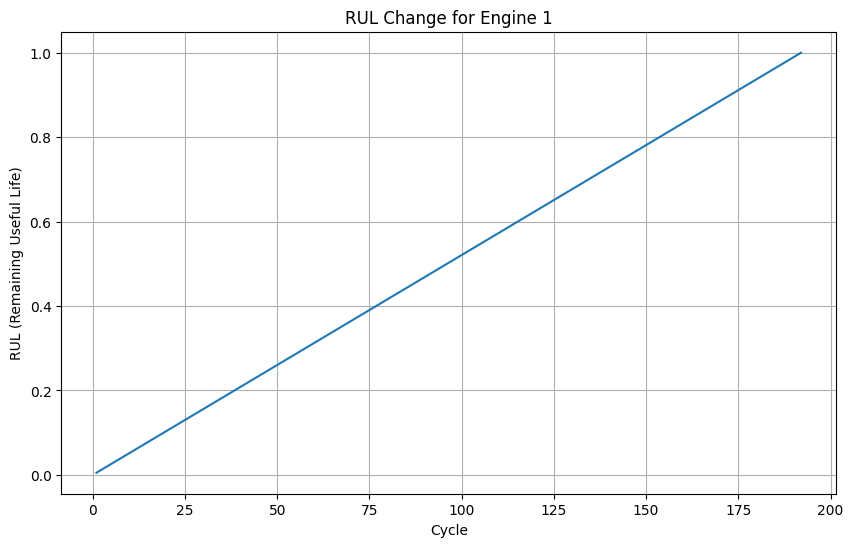

In [36]:
# Filter dftrain1 for engine 1
engine_1_data = dftrain1[dftrain1['engine'] == 1]

plt.figure(figsize=(10, 6))
plt.plot(engine_1_data['cycle'], engine_1_data['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL (Remaining Useful Life)')
plt.title('RUL Change for Engine 1')
plt.grid(True)
plt.show()


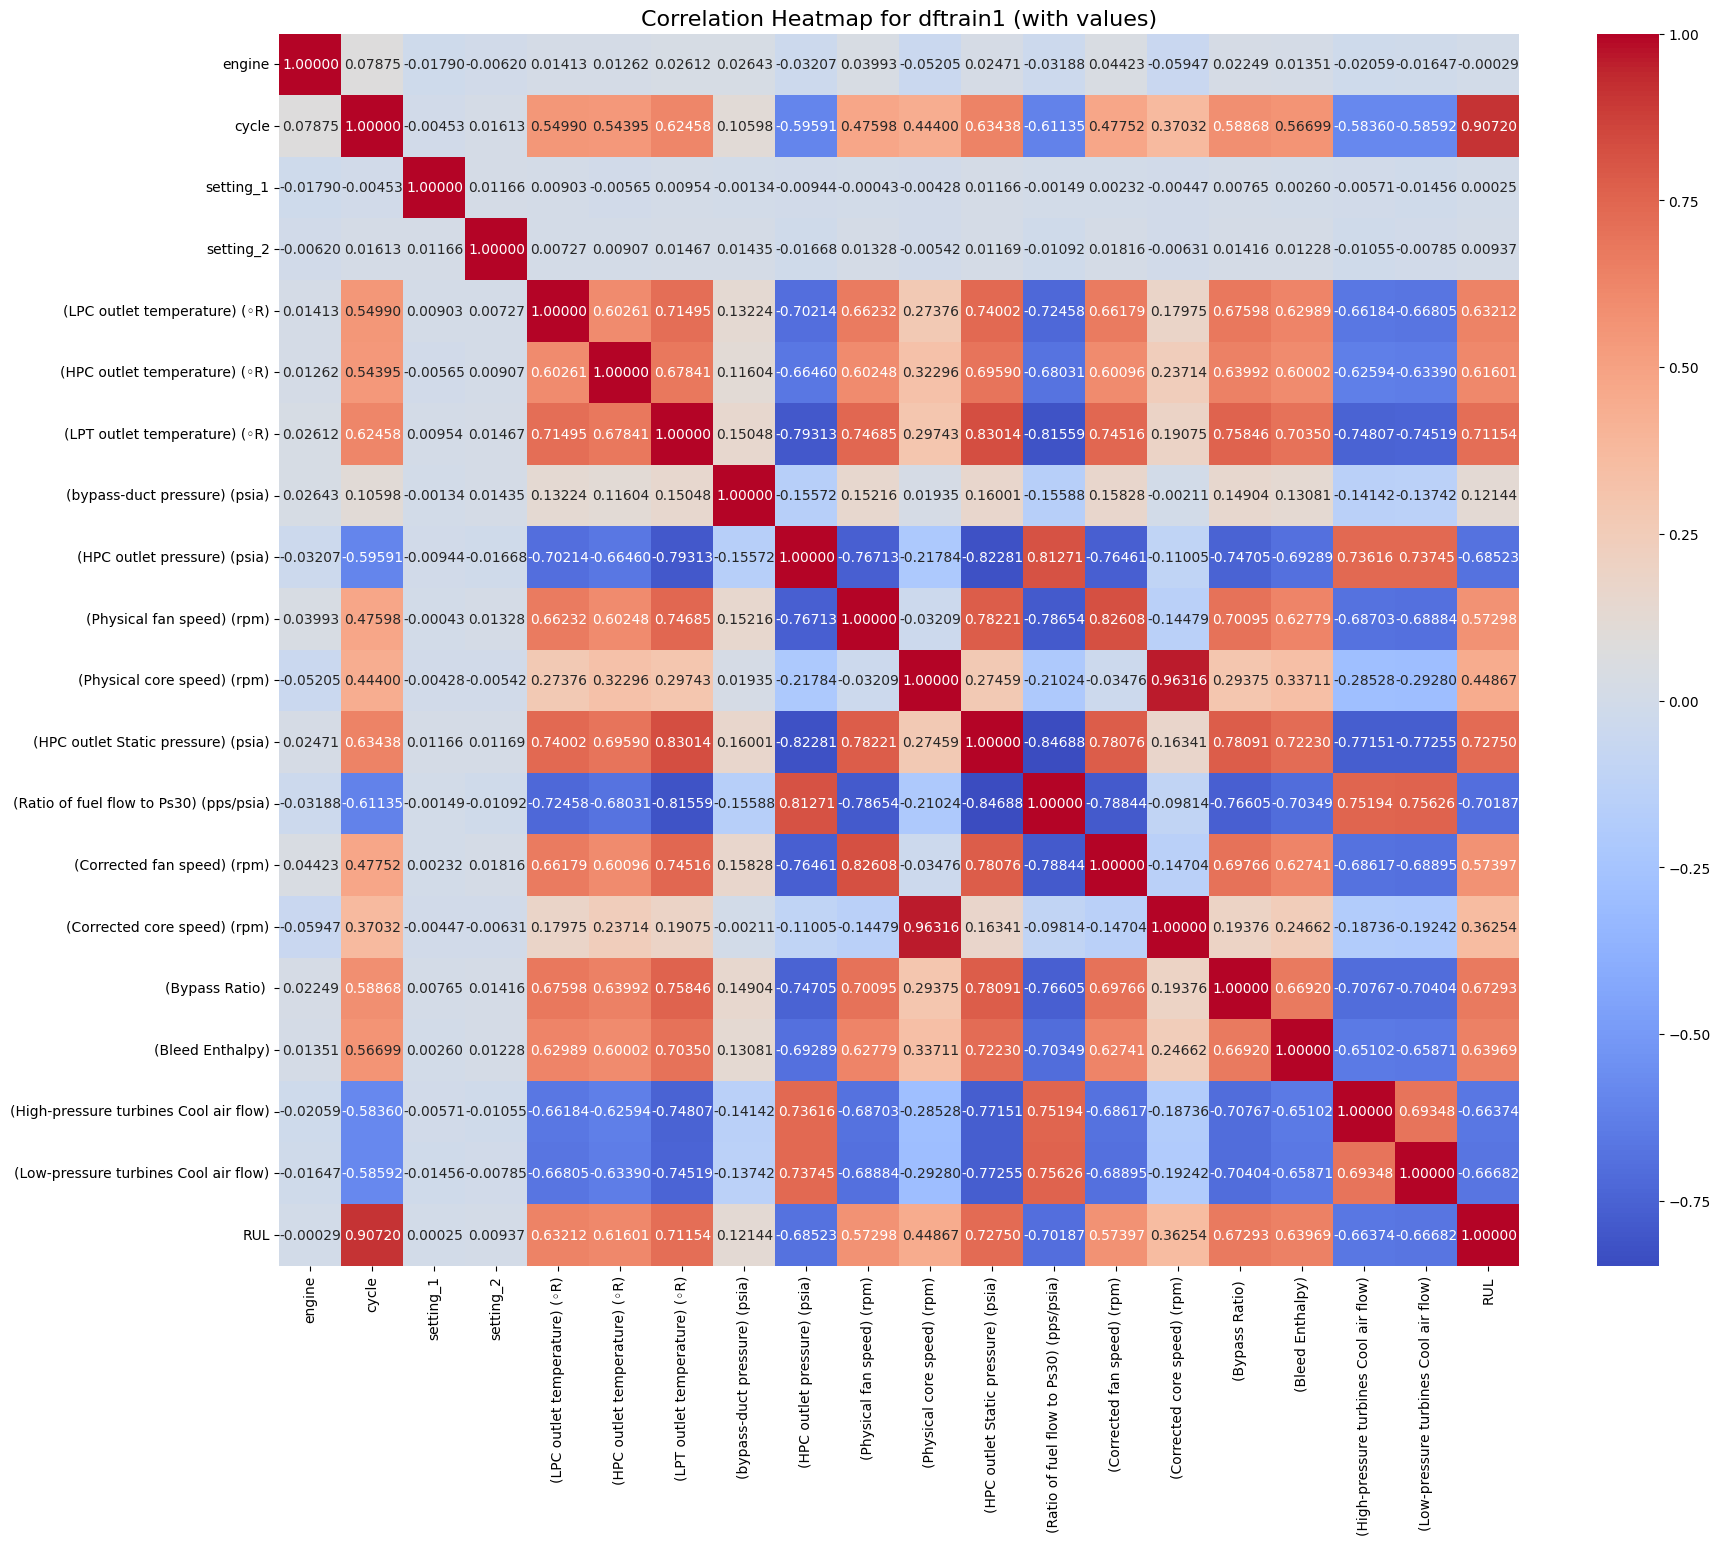

In [37]:
# Calculate the correlation matrix
correlation_matrix = dftrain1.corr()

# Create a heatmap with annotations and increased figure size
plt.figure(figsize=(20, 16)) # Increased figsize for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".5f") # annot=True to display values
plt.title('Correlation Heatmap for dftrain1 (with values)', fontsize=16)
plt.show()


It can be seen that features 'engine', 'setting_1',    'setting_2', 'bypass-duct pressure' are weakly correlated to RUL, hence those features can be dropped.

In [38]:
dftrain1.drop(columns=['engine', 'setting_1', 'setting_2', '(bypass-duct pressure) (psia)'], inplace=True)

In [39]:
dftrain1.describe()

,cycle,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,108.807862,642.680934,1590.523119,1408.933782,553.367711,2388.096652,9065.242941,47.541168,521.413470,2388.096152,8143.752722,8.442146,393.210654,38.816271,23.289705,0.502424
std,68.880990,0.500053,6.131150,9.000605,0.885092,0.070985,22.082880,0.267087,0.737553,0.071919,19.076176,0.037505,1.548763,0.180746,0.108251,0.288679
min,1.000000,641.210000,1571.040000,1382.250000,549.850000,2387.900000,9021.730000,46.850000,518.690000,2387.880000,8099.940000,8.324900,388.000000,38.140000,22.894200,0.002762
25%,52.000000,642.325000,1586.260000,1402.360000,552.810000,2388.050000,9053.100000,47.350000,520.960000,2388.040000,8133.245000,8.414900,392.000000,38.700000,23.221800,0.252475
50%,104.000000,642.640000,1590.100000,1408.040000,553.440000,2388.090000,9060.660000,47.510000,521.480000,2388.090000,8140.540000,8.438900,393.000000,38.830000,23.297900,0.502488
75%,156.000000,643.000000,1594.380000,1414.555000,554.010000,2388.140000,9069.420000,47.700000,521.950000,2388.140000,8148.310000,8.465600,394.000000,38.950000,23.366800,0.752551
max,362.000000,644.530000,1616.910000,1441.490000,556.060000,2388.560000,9244.590000,48.530000,523.380000,2388.560000,8293.720000,8.584800,400.000000,39.430000,23.618400,1.000000


# Analyzing some factors affecting RUL values

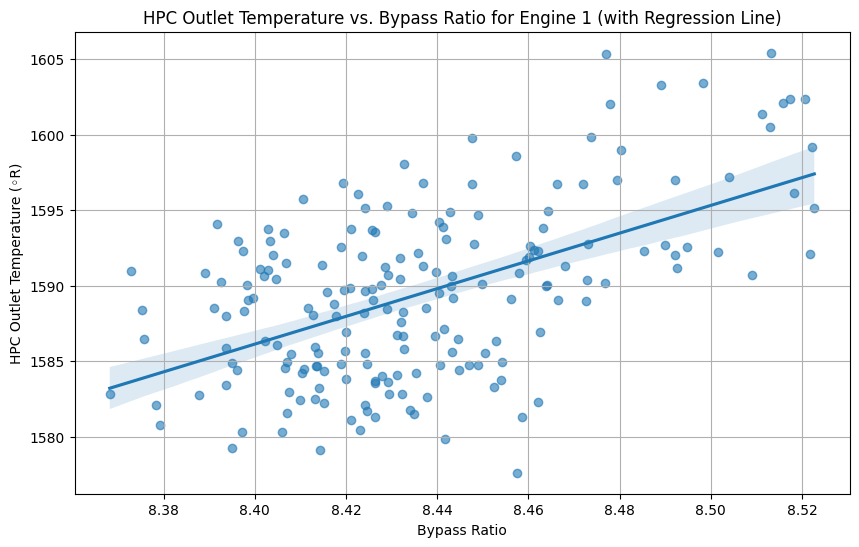

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload dftrain1 to get the 'engine' column back for this specific plot
temp_dftrain1 = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)

# Filter for engine 1
engine_1_data_for_plot = temp_dftrain1[temp_dftrain1['engine'] == 1]

plt.figure(figsize=(10, 6))
sns.regplot(x=engine_1_data_for_plot['(Bypass Ratio) '], y=engine_1_data_for_plot['(HPC outlet temperature) (◦R)'], scatter_kws={'alpha':0.6})
plt.xlabel('Bypass Ratio')
plt.ylabel('HPC Outlet Temperature (◦R)')
plt.title('HPC Outlet Temperature vs. Bypass Ratio for Engine 1 (with Regression Line)')
plt.grid(True)
plt.show()

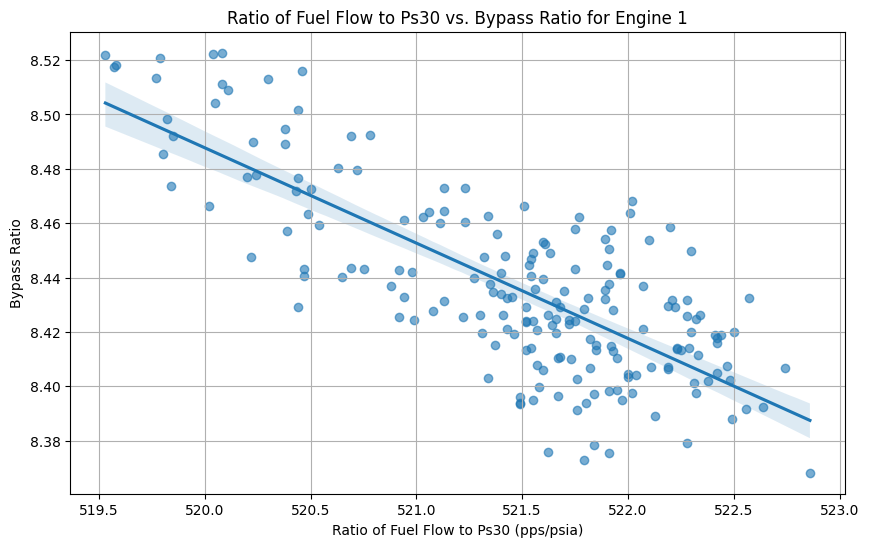

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload dftrain1 to get the 'engine' column back for this specific plot
temp_dftrain1 = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)

# Filter for engine 1
engine_1_data_for_plot = temp_dftrain1[temp_dftrain1['engine'] == 1]

plt.figure(figsize=(10, 6))
sns.regplot(x=engine_1_data_for_plot['(Ratio of fuel flow to Ps30) (pps/psia)'], y=engine_1_data_for_plot['(Bypass Ratio) '], scatter_kws={'alpha':0.6})
plt.xlabel('Ratio of Fuel Flow to Ps30 (pps/psia)')
plt.ylabel('Bypass Ratio')
plt.title('Ratio of Fuel Flow to Ps30 vs. Bypass Ratio for Engine 1')
plt.grid(True)
plt.show()

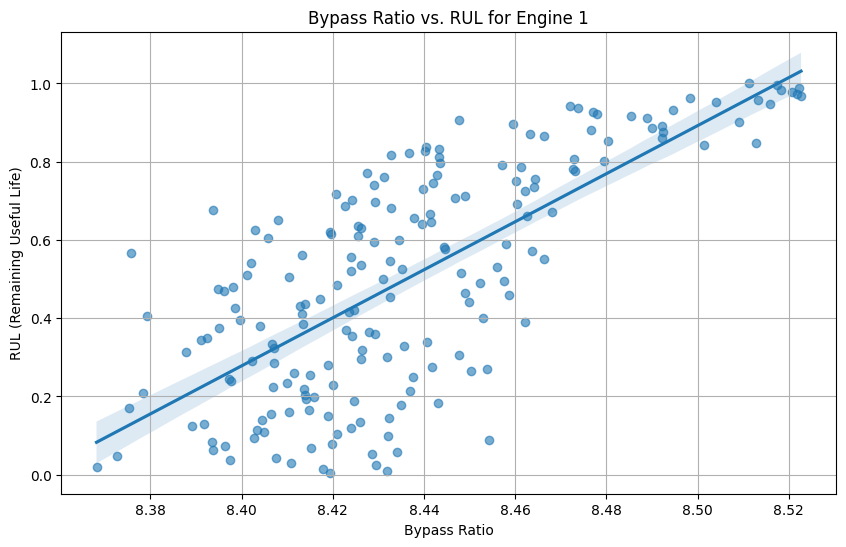

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The following lines are needed to ensure 'engine_1_data_for_plot_3d' is prepared:
temp_dftrain1 = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
max_cycles_temp = temp_dftrain1.groupby('engine')['cycle'].transform('max')
temp_dftrain1['RUL'] = temp_dftrain1['cycle'] / max_cycles_temp
engine_1_data_for_plot_3d = temp_dftrain1[temp_dftrain1['engine'] == 1]

plt.figure(figsize=(10, 6))
sns.regplot(x=engine_1_data_for_plot_3d['(Bypass Ratio) '], y=engine_1_data_for_plot_3d['RUL'], scatter_kws={'alpha':0.6})
plt.xlabel('Bypass Ratio')
plt.ylabel('RUL (Remaining Useful Life)')
plt.title('Bypass Ratio vs. RUL for Engine 1')
plt.grid(True)
plt.show()

The example of Engine 1 in this test shows thats as the Bypass Ratio of the engine is increased, the HPC Outlet Temperature is also increasinng. This is suggestive of the engine working harder to compensate for less air moving through the core. It can be inferred that overtime such intensive load can increase wear of componenents which can reduce their efficiency. From the scatter plot between RUL value (Actually Life Ratio) is approaching 1.00 (Which means nearing failure condition) as Bypass Ratio of the engine increases.

Let us now take the example of an engine that approached failure the fastest in the test and compare the Bypass Ratio values with that of Engine 1.

In [43]:
max_cycles_per_engine_dftrain1 = raw_dftrain1.groupby('engine')['cycle'].max().reset_index()
least_max_cycle_engine_dftrain1 = max_cycles_per_engine_dftrain1.loc[max_cycles_per_engine_dftrain1['cycle'].idxmin()]

print(f"For dftrain1, the engine with the least maximum cycle value is Engine {int(least_max_cycle_engine_dftrain1['engine'])} with a maximum cycle of {int(least_max_cycle_engine_dftrain1['cycle'])}.")

For dftrain1, the engine with the least maximum cycle value is Engine 39 with a maximum cycle of 128.


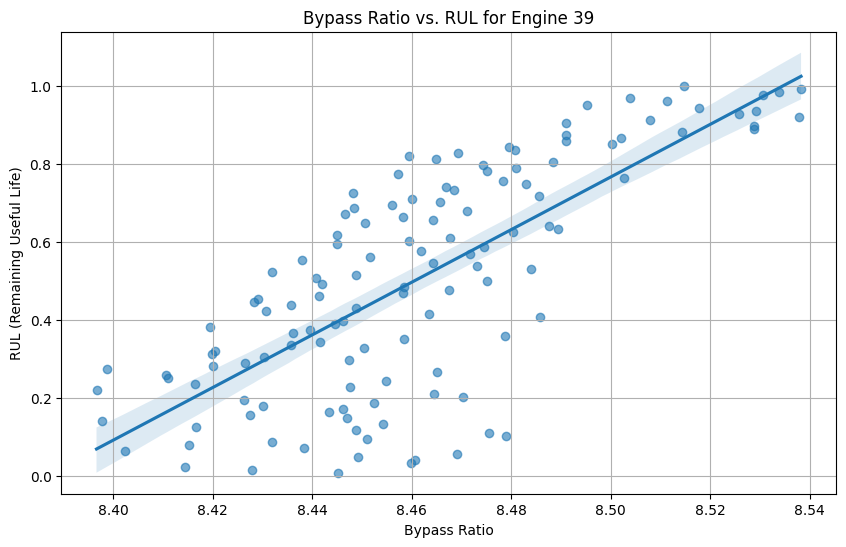

In [44]:
# Filter raw_dftrain1 for engine 39
engine_39_data = raw_dftrain1[raw_dftrain1['engine'] == 39]

# Calculate max cycles for engine 39 to determine RUL
max_cycles_engine_39 = engine_39_data['cycle'].max()
engine_39_data['RUL'] = (engine_39_data['cycle'] / max_cycles_engine_39)

plt.figure(figsize=(10, 6))
sns.regplot(x=engine_39_data['(Bypass Ratio) '], y=engine_39_data['RUL'], scatter_kws={'alpha':0.6})
plt.xlabel('Bypass Ratio')
plt.ylabel('RUL (Remaining Useful Life)')
plt.title('Bypass Ratio vs. RUL for Engine 39')
plt.grid(True)
plt.show()

Descriptive Statistics for Bypass Ratio - Engine 1:
count    192.000000
mean       8.436555
std        0.034125
min        8.368200
25%        8.413275
50%        8.431150
75%        8.457275
max        8.522700
Name: (Bypass Ratio) , dtype: float64

Descriptive Statistics for Bypass Ratio - Engine 39:
count    128.000000
mean       8.461070
std        0.031873
min        8.396600
25%        8.441175
50%        8.458400
75%        8.479150
max        8.538300
Name: (Bypass Ratio) , dtype: float64


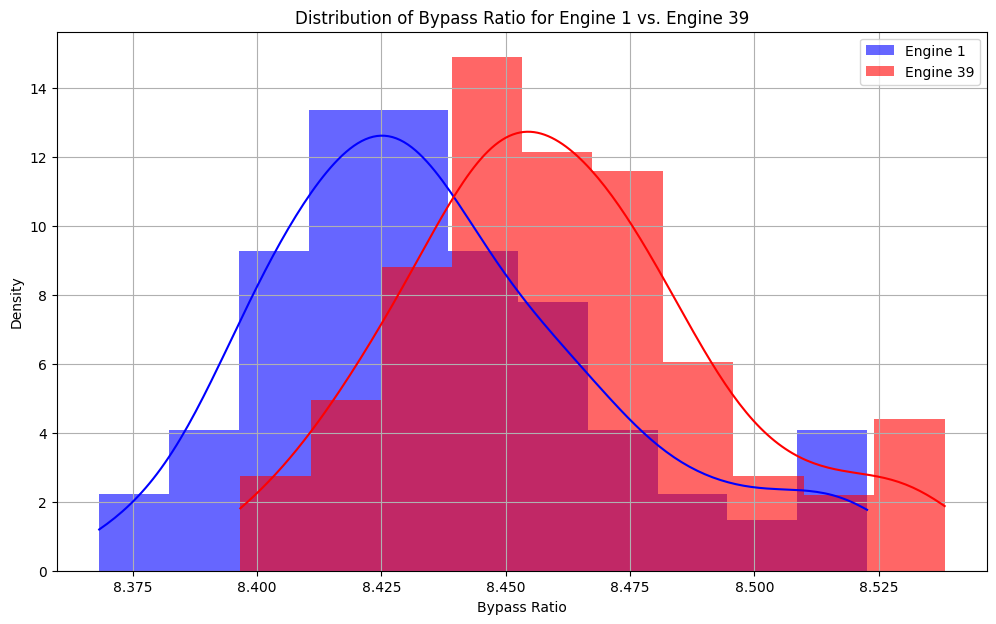

In [45]:
# Extract Bypass Ratio for Engine 1
engine_1_bypass_ratio = raw_dftrain1[raw_dftrain1['engine'] == 1]['(Bypass Ratio) ']

# Extract Bypass Ratio for Engine 39
engine_39_bypass_ratio = raw_dftrain1[raw_dftrain1['engine'] == 39]['(Bypass Ratio) ']

print("Descriptive Statistics for Bypass Ratio - Engine 1:")
print(engine_1_bypass_ratio.describe())
print("\nDescriptive Statistics for Bypass Ratio - Engine 39:")
print(engine_39_bypass_ratio.describe())

# Plotting the distributions for comparison
plt.figure(figsize=(12, 7))
sns.histplot(engine_1_bypass_ratio, kde=True, color='blue', label='Engine 1', alpha=0.6, stat='density', linewidth=0)
sns.histplot(engine_39_bypass_ratio, kde=True, color='red', label='Engine 39', alpha=0.6, stat='density', linewidth=0)
plt.title('Distribution of Bypass Ratio for Engine 1 vs. Engine 39')
plt.xlabel('Bypass Ratio')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
max_cycles_per_engine_dftrain1 = raw_dftrain1.groupby('engine')['cycle'].max().reset_index()

least_max_cycle_engine_dftrain1 = max_cycles_per_engine_dftrain1.loc[max_cycles_per_engine_dftrain1['cycle'].idxmax()]

print(f"For dftrain1, the engine with the most maximum cycle value is Engine {int(least_max_cycle_engine_dftrain1['engine'])} with a maximum cycle of {int(least_max_cycle_engine_dftrain1['cycle'])}.")

For dftrain1, the engine with the most maximum cycle value is Engine 69 with a maximum cycle of 362.


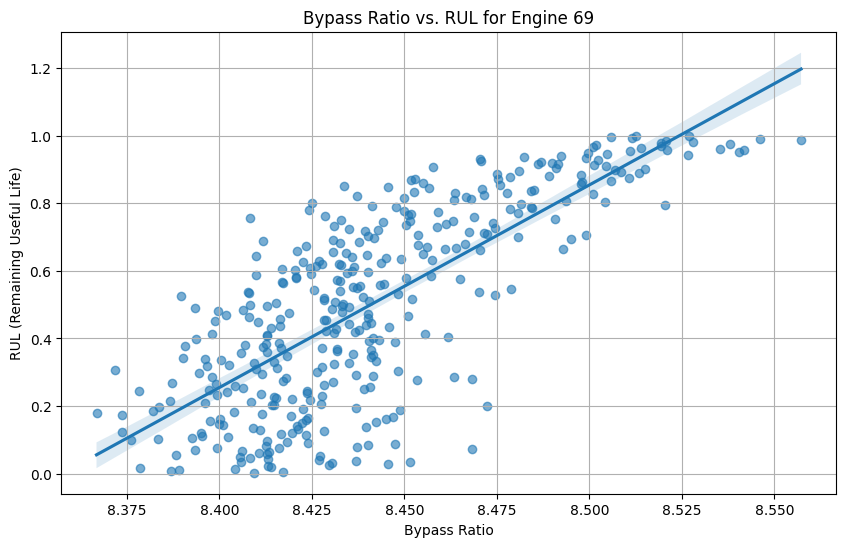

In [47]:
engine_69_data = raw_dftrain1[raw_dftrain1['engine'] == 69]

# Calculate max cycles for engine 39 to determine RUL
max_cycles_engine_69 = engine_69_data['cycle'].max()
engine_69_data['RUL'] = (engine_69_data['cycle'] / max_cycles_engine_69)

plt.figure(figsize=(10, 6))
sns.regplot(x=engine_69_data['(Bypass Ratio) '], y=engine_69_data['RUL'], scatter_kws={'alpha':0.6})
plt.xlabel('Bypass Ratio')
plt.ylabel('RUL (Remaining Useful Life)')
plt.title('Bypass Ratio vs. RUL for Engine 69')
plt.grid(True)
plt.show()

Descriptive Statistics for Bypass Ratio - Engine 1:
count    192.000000
mean       8.436555
std        0.034125
min        8.368200
25%        8.413275
50%        8.431150
75%        8.457275
max        8.522700
Name: (Bypass Ratio) , dtype: float64

Descriptive Statistics for Bypass Ratio - Engine 39:
count    128.000000
mean       8.461070
std        0.031873
min        8.396600
25%        8.441175
50%        8.458400
75%        8.479150
max        8.538300
Name: (Bypass Ratio) , dtype: float64

Descriptive Statistics for Bypass Ratio - Engine 69:
count    362.000000
mean       8.441169
std        0.036559
min        8.366800
25%        8.414800
50%        8.435050
75%        8.462750
max        8.557200
Name: (Bypass Ratio) , dtype: float64


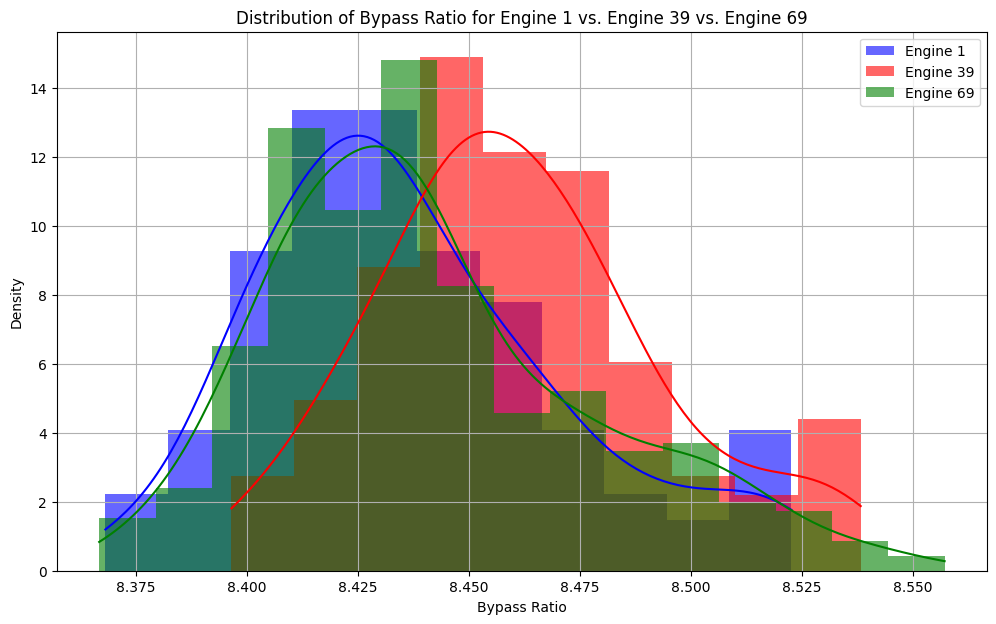

In [48]:
# Extract Bypass Ratio for Engine 1
engine_1_bypass_ratio = raw_dftrain1[raw_dftrain1['engine'] == 1]['(Bypass Ratio) ']

# Extract Bypass Ratio for Engine 39
engine_39_bypass_ratio = raw_dftrain1[raw_dftrain1['engine'] == 39]['(Bypass Ratio) ']

# Extract Bypass Ratio for Engine 39
engine_69_bypass_ratio = raw_dftrain1[raw_dftrain1['engine'] == 69]['(Bypass Ratio) ']

print("Descriptive Statistics for Bypass Ratio - Engine 1:")
print(engine_1_bypass_ratio.describe())
print("\nDescriptive Statistics for Bypass Ratio - Engine 39:")
print(engine_39_bypass_ratio.describe())
print("\nDescriptive Statistics for Bypass Ratio - Engine 69:")
print(engine_69_bypass_ratio.describe())

# Plotting the distributions for comparison
plt.figure(figsize=(12, 7))
sns.histplot(engine_1_bypass_ratio, kde=True, color='blue', label='Engine 1', alpha=0.6, stat='density', linewidth=0)
sns.histplot(engine_39_bypass_ratio, kde=True, color='red', label='Engine 39', alpha=0.6, stat='density', linewidth=0)
sns.histplot(engine_69_bypass_ratio, kde=True, color='green', label='Engine 69', alpha=0.6, stat='density', linewidth=0)
plt.title('Distribution of Bypass Ratio for Engine 1 vs. Engine 39 vs. Engine 69')
plt.xlabel('Bypass Ratio')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

From comparison of the 3 engines - Engine 39 (Failed fastest), Engine 69 (Failed latest), Engine 1 (Failed earlier than 69 but later than 39)
It can be concluded that Bypass Ratio has a significant effect on RUL of an engine. Higher Bypass Ratios increase fuel efficiency in modern turbofan. However, it is important to consider the wear in components caused due to very high HBR configurations.

# Preparing all the 4 datasets to be trained

In [49]:
columns_to_drop = [
    'engine',
    'setting_1',
    'setting_2',
    'setting_3',
    '(Fan inlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(Engine pressure ratio(P50/P2)',
    '(Burner fuel-air ratio)',
    '(Required fan speed)',
    '(Required fan conversion speed)',
    '(bypass-duct pressure) (psia)',
]

processed_training_dataframes = {}

# Using the raw dataframes to ensure all original columns are present for consistent processing.
raw_training_dataframes_dict = {
    'dftrain1': raw_dftrain1.copy(),
    'dftrain2': raw_dftrain2.copy(),
    'dftrain3': raw_dftrain3.copy(),
    'dftrain4': raw_dftrain4.copy()
}

for df_name, df_data in raw_training_dataframes_dict.items():
    # Calculate RUL (life_ratio) as current_cycle / max_cycle for each engine
    max_cycles_current_df = df_data.groupby('engine')['cycle'].transform('max')
    df_data['RUL'] = df_data['cycle'] / max_cycles_current_df

    existing_cols_to_drop = [col for col in columns_to_drop if col in df_data.columns]
    df_data.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

    processed_training_dataframes[df_name] = df_data
    print(f"Processed {df_name}, new shape: {df_data.shape}")

# Concatenate all processed training dataframes for X_train and y_train
# X_train will contain all features except 'RUL'
X_train_combined = pd.concat([df.drop(columns=['RUL']) for df_name, df in processed_training_dataframes.items()], ignore_index=True)
# y_train will contain only the 'RUL' values
y_train_combined = pd.concat([df['RUL'] for df_name, df in processed_training_dataframes.items()], ignore_index=True)

print(f"\nCombined X_train shape: {X_train_combined.shape}")
print(f"Combined y_train shape: {y_train_combined.shape}")

# Update the global dataframe references with the processed versions
dftrain1 = processed_training_dataframes['dftrain1']
dftrain2 = processed_training_dataframes['dftrain2']
dftrain3 = processed_training_dataframes['dftrain3']
dftrain4 = processed_training_dataframes['dftrain4']

Processed dftrain1, new shape: (20631, 16)
Processed dftrain2, new shape: (53759, 16)
Processed dftrain3, new shape: (24720, 16)
Processed dftrain4, new shape: (61249, 16)

Combined X_train shape: (160359, 15)
Combined y_train shape: (160359,)


# Training Random Forest Regressor

In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training Random Forest Regressor...")
rf_regressor.fit(X_train_combined, y_train_combined)
print("Random Forest Regressor training complete!")

Training Random Forest Regressor...
Random Forest Regressor training complete!


# Training XGBoost model-

The research paper *Damage Propagation Modeling for Aircraft
Engine Run-to-Failure Simulation * mentions about Asymmetric Scoring while making predictions, eg: If predicted RUL is later than the true RUL, then the scoring should be more  heavily penalized as compared to predicting RUL early. An engine failing before the estimated time of failure can be catastrophic. Hence the paper suggests a custom scoring function that can be applied to deal with this issue. Also it is suggested to check for a correlation score to maintain "Fleet Consistency" among engines.

XGBoost is one of the best models to work with in this scenario as it allows the user to write a custom objective function.

In [51]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. NEW: Time-Weighted Asymmetric Objective ---
def time_weighted_fractional_objective(y_pred, dtrain):
    """
    Adapted for life_ratio [0, 1] with Time-Dependent Weighting.
    Penalizes errors more heavily as the engine approaches failure (y_true -> 1).
    """
    y_true = dtrain.get_label()

    # Scale fractional error to roughly match cycle magnitudes (~200)
    cycle_scaler = 108.0

    # Reverse logic: positive 'd' now means LATE prediction
    d = (y_true - y_pred) * cycle_scaler

    grad = np.zeros_like(d)
    hess = np.zeros_like(d)

    a1 = 10.0 # Conservative penalty
    a2 = 13.0 # Dangerous penalty

    # As y_true approaches 1 (failure), this weight scales up exponentially.
    urgency_weight = np.exp(y_true * 1.5)

    # Late Prediction (Dangerous, y_pred < y_true -> d > 0)
    late_mask = d > 0
    grad[late_mask] = -(cycle_scaler / a2) * np.exp(d[late_mask] / a2) * urgency_weight[late_mask]
    hess[late_mask] = ((cycle_scaler / a2) ** 2) * np.exp(d[late_mask] / a2) * urgency_weight[late_mask]

    # Early Prediction (Conservative, y_pred >= y_true -> d <= 0)
    early_mask = d <= 0
    grad[early_mask] = (cycle_scaler / a1) * np.exp(-d[early_mask] / a1) * urgency_weight[early_mask]
    hess[early_mask] = ((cycle_scaler / a1) ** 2) * np.exp(-d[early_mask] / a1) * urgency_weight[early_mask]

    # Clip gradients to prevent explosion
    grad = np.clip(grad, -1e5, 1e5)
    hess = np.clip(hess, 1e-5, 1e5)

    return grad, hess

# --- 2. Existing PHM Score Functions---
def phm_fractional_score(y_true, y_pred):
    """
    Calculates the aggregate paper score adjusted for fractional targets.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    cycle_scaler = 108.0
    d = (y_true - y_pred) * cycle_scaler

    a1 = 10.0
    a2 = 13.0
    scores = np.zeros_like(d, dtype=np.float64)

    early_mask = d <= 0
    scores[early_mask] = np.exp(-d[early_mask] / a1) - 1.0

    late_mask = d > 0
    scores[late_mask] = np.exp(d[late_mask] / a2) - 1.0

    return np.sum(scores)

def eval_phm_fractional(y_pred, dtrain):
    y_true = dtrain.get_label()
    score = phm_fractional_score(y_true, y_pred)
    return 'phm_score', float(score)

# ---Fleet Correlation Metric ---
def evaluate_fleet_correlation(df, true_col, pred_col, uut_col='unit_number'):
    """
    Calculates the average Pearson correlation between predicted and true RUL
    across individual engines (Units Under Test) to measure consistency.
    """
    correlations = []

    # Group the dataframe by individual engines
    for unit, group_data in df.groupby(uut_col):
        y_true_uut = group_data[true_col].values
        y_pred_uut = group_data[pred_col].values

        # Pearson correlation requires at least 2 data points with some variance
        if len(y_true_uut) > 1 and np.std(y_true_uut) > 0:
            corr, _ = pearsonr(y_true_uut, y_pred_uut)

            if not np.isnan(corr):
                correlations.append(corr)

    # Return the average correlation across the entire fleet
    return np.mean(correlations)


dtrain = xgb.DMatrix(X_train_combined, label=y_train_combined)

params = {
    'eta': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

print("\nTraining XGBoost with Time-Weighted Fractional Asymmetric Objective...")
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=150,
    obj=time_weighted_fractional_objective,
    custom_metric=eval_phm_fractional,
    evals=[(dtrain, 'train')]
)
print("XGBoost training complete!")

y_pred_xgb = xgb_model.predict(dtrain)

mse_xgb = mean_squared_error(y_train_combined, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_train_combined, y_pred_xgb)
phm_score_xgb = phm_fractional_score(y_train_combined, y_pred_xgb)

print(f"\n--- XGBoost Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}") # Added RMSE print
print(f"R-squared (R2) Score: {r2_xgb:.4f}")
print(f"Official PHM08 Challenge Score (Adjusted): {phm_score_xgb:.4f}")

# --- Evaluating Fleet Consistency ---

# Create a list to store dataframes for correlation calculation
list_dfs_for_correlation = []

# Using the original raw dataframes to maintain 'engine' column
raw_dfs = [raw_dftrain1.copy(), raw_dftrain2.copy(), raw_dftrain3.copy(), raw_dftrain4.copy()]

columns_to_drop_for_correlation = [
    'setting_1',
    'setting_2',
    'setting_3',
    '(Fan inlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(Engine pressure ratio(P50/P2)',
    '(Burner fuel-air ratio)',
    '(Required fan speed)',
    '(Required fan conversion speed)',
    '(bypass-duct pressure) (psia)'
]

for df_data in raw_dfs:
    # Calculate RUL (life_ratio) as current_cycle / max_cycle for each engine
    max_cycles_current_df = df_data.groupby('engine')['cycle'].transform('max')
    df_data['RUL'] = df_data['cycle'] / max_cycles_current_df

    # Drop columns that are no longer needed or were identified as irrelevant, but keep 'engine' and 'cycle'
    existing_cols_to_drop = [col for col in columns_to_drop_for_correlation if col in df_data.columns]
    df_data.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

    list_dfs_for_correlation.append(df_data)


train_data_full_for_correlation = pd.concat(list_dfs_for_correlation, ignore_index=True)

train_data_full_for_correlation['predicted_life_ratio'] = y_pred_xgb

fleet_correlation = evaluate_fleet_correlation(
    df=train_data_full_for_correlation,
    true_col='RUL',
    pred_col='predicted_life_ratio',
    uut_col='engine'
)

print(f"\nAverage Fleet Correlation Score: {fleet_correlation:.4f}")

if fleet_correlation > 0.90:
    print("Status: Excellent. The algorithm has a consistent, predictable bias across the fleet.")
elif fleet_correlation < 0.50:
    print("Status: Warning. The algorithm is guessing erratically across different engines.")


Training XGBoost with Time-Weighted Fractional Asymmetric Objective...
[0]	train-rmse:0.28576	train-phm_score:4103461.40184
[1]	train-rmse:0.28156	train-phm_score:3901948.64969
[2]	train-rmse:0.27739	train-phm_score:3710582.13914
[3]	train-rmse:0.27325	train-phm_score:3528700.20915
[4]	train-rmse:0.26915	train-phm_score:3355959.63430
[5]	train-rmse:0.26508	train-phm_score:3191951.74370
[6]	train-rmse:0.26105	train-phm_score:3036105.72961
[7]	train-rmse:0.25707	train-phm_score:2888299.86766
[8]	train-rmse:0.25312	train-phm_score:2747682.12459
[9]	train-rmse:0.24920	train-phm_score:2614040.01746
[10]	train-rmse:0.24533	train-phm_score:2487441.16249
[11]	train-rmse:0.24151	train-phm_score:2367281.85594
[12]	train-rmse:0.23773	train-phm_score:2253398.95415
[13]	train-rmse:0.23398	train-phm_score:2145294.43438
[14]	train-rmse:0.23112	train-phm_score:2064118.88010
[15]	train-rmse:0.22743	train-phm_score:1965272.82415
[16]	train-rmse:0.22378	train-phm_score:1871621.86499
[17]	train-rmse:0.22

# Visualizing model performance using Training Data

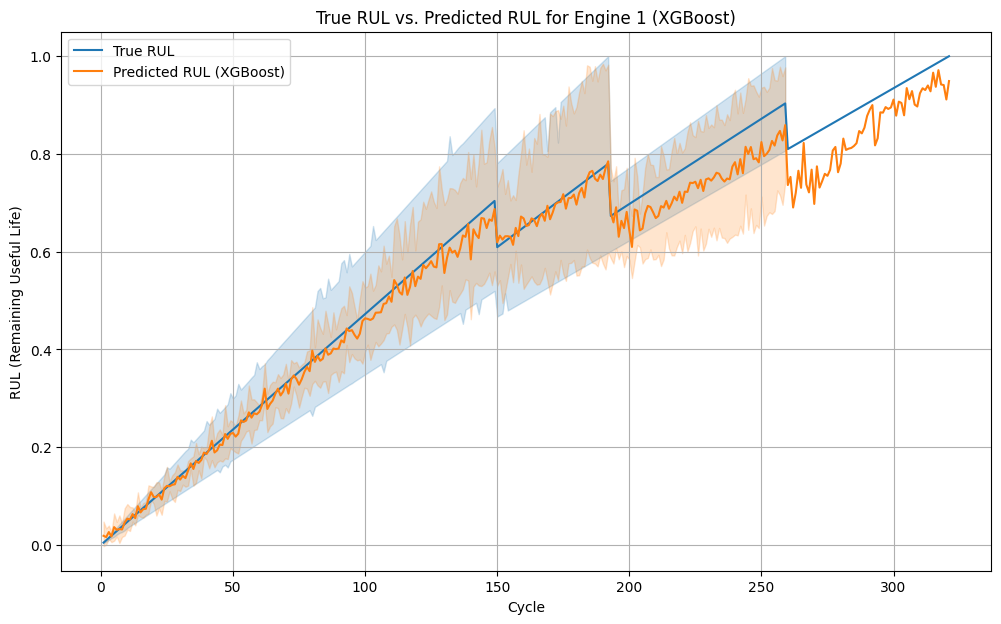

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the combined training data for Engine 1
engine_1_predictions = train_data_full_for_correlation[train_data_full_for_correlation['engine'] == 1]

plt.figure(figsize=(12, 7))
sns.lineplot(x='cycle', y='RUL', data=engine_1_predictions, label='True RUL')
sns.lineplot(x='cycle', y='predicted_life_ratio', data=engine_1_predictions, label='Predicted RUL (XGBoost)')

plt.title('True RUL vs. Predicted RUL for Engine 1 (XGBoost)')
plt.xlabel('Cycle')
plt.ylabel('RUL (Remaining Useful Life)')
plt.grid(True)
plt.legend()
plt.show()

# Testing model performance on Test Data

In [53]:
dftest1 = pd.read_csv('test_FD001.txt', sep="\s+", header=None, names=col_names)
dftest2 = pd.read_csv('test_FD002.txt', sep="\s+", header=None, names=col_names)
dftest3 = pd.read_csv('test_FD003.txt', sep="\s+", header=None, names=col_names)
dftest4 = pd.read_csv('test_FD004.txt', sep="\s+", header=None, names=col_names)

# Load raw test dataframes for consistent processing
raw_dftest1 = dftest1.copy()
raw_dftest2 = dftest2.copy()
raw_dftest3 = dftest3.copy()
raw_dftest4 = dftest4.copy()

raw_test_dataframes_dict = {
    'dftest1': raw_dftest1,
    'dftest2': raw_dftest2,
    'dftest3': raw_dftest3,
    'dftest4': raw_dftest4
}

# Load RUL files for test data
rul_FD001 = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])
rul_FD002 = pd.read_csv('RUL_FD002.txt', sep='\s+', header=None, names=['RUL'])
rul_FD003 = pd.read_csv('RUL_FD003.txt', sep='\s+', header=None, names=['RUL'])
rul_FD004 = pd.read_csv('RUL_FD004.txt', sep='\s+', header=None, names=['RUL'])

rul_files_dict = {
    'dftest1': rul_FD001,
    'dftest2': rul_FD002,
    'dftest3': rul_FD003,
    'dftest4': rul_FD004
}

processed_test_dataframes = {}

# Columns to drop, same as training data preparation
columns_to_drop = [
    'engine', # Needed for RUL calculation/groupby, then dropped for features
    'setting_1',
    'setting_2',
    'setting_3',
    '(Fan inlet temperature) (◦R)',
    '(Fan inlet Pressure) (psia)',
    '(Engine pressure ratio(P50/P2)',
    '(Burner fuel-air ratio)',
    '(Required fan speed)',
    '(Required fan conversion speed)',
    '(bypass-duct pressure) (psia)',
]

for df_name, df_data in raw_test_dataframes_dict.items():
    print(f"Processing {df_name}...")

    # Identify the last cycle for each engine in the test set
    max_cycles_test_df_per_engine = df_data.groupby('engine')['cycle'].max().reset_index()

    # Get the true RUL for the *last observed cycle* of each engine from the RUL file
    temp_rul_df = max_cycles_test_df_per_engine.copy()
    temp_rul_df['true_remaining_cycles'] = rul_files_dict[df_name]['RUL'].values
    temp_rul_df['total_lifespan'] = temp_rul_df['cycle'] + temp_rul_df['true_remaining_cycles']

    # Merge this back into the main dataframe to get 'total_lifespan' for each row
    df_data = pd.merge(df_data, temp_rul_df[['engine', 'total_lifespan']], on='engine', how='left')

    # Calculate RUL as 'cycle / total_lifespan' (fractional life completed, consistent with training)
    df_data['RUL'] = df_data['cycle'] / df_data['total_lifespan']

    # Drop the temporary 'total_lifespan' column
    df_data.drop(columns=['total_lifespan'], inplace=True)

    # Drop columns that were removed from training data
    existing_cols_to_drop = [col for col in columns_to_drop if col in df_data.columns]
    df_data.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

    processed_test_dataframes[df_name] = df_data
    print(f"  Processed {df_name}, new shape: {df_data.shape}")

# Concatenate all processed test dataframes for X_test and y_test
X_test_combined = pd.concat([df.drop(columns=['RUL']) for df_name, df in processed_test_dataframes.items()], ignore_index=True)
y_test_combined = pd.concat([df['RUL'] for df_name, df in processed_test_dataframes.items()], ignore_index=True)

print(f"\nCombined X_test shape: {X_test_combined.shape}")
print(f"Combined y_test shape: {y_test_combined.shape}")

# Update the global dataframe references with the processed versions (optional, but good practice if these are used later)
dftest1 = processed_test_dataframes['dftest1']
dftest2 = processed_test_dataframes['dftest2']
dftest3 = processed_test_dataframes['dftest3']
dftest4 = processed_test_dataframes['dftest4']

Processing dftest1...
  Processed dftest1, new shape: (13096, 16)
Processing dftest2...
  Processed dftest2, new shape: (33991, 16)
Processing dftest3...
  Processed dftest3, new shape: (16596, 16)
Processing dftest4...
  Processed dftest4, new shape: (41214, 16)

Combined X_test shape: (104897, 15)
Combined y_test shape: (104897,)


Testing on XGBoost

In [54]:
# Make predictions on the test data
dtest = xgb.DMatrix(X_test_combined, label=y_test_combined)
y_pred_xgb_test = xgb_model.predict(dtest)

# Calculate standard and custom metrics for test data
mse_xgb_test = mean_squared_error(y_test_combined, y_pred_xgb_test)
rmse_xgb_test = np.sqrt(mse_xgb_test)
r2_xgb_test = r2_score(y_test_combined, y_pred_xgb_test)
phm_score_xgb_test = phm_fractional_score(y_test_combined, y_pred_xgb_test)

print(f"\n--- XGBoost Model Performance on TEST Data ---")
print(f"Mean Squared Error (MSE): {mse_xgb_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_test:.4f}")
print(f"R-squared (R2) Score: {r2_xgb_test:.4f}")
print(f"Official PHM08 Challenge Score (Adjusted): {phm_score_xgb_test:.4f}")

# --- Evaluating Fleet Consistency on TEST Data ---

# Create a list to store dataframes for correlation calculation on test data
list_test_dfs_for_correlation = []

# Using the original raw test dataframes to maintain 'engine' column
raw_test_dfs = [raw_dftest1.copy(), raw_dftest2.copy(), raw_dftest3.copy(), raw_dftest4.copy()]

for i, df_data in enumerate(raw_test_dfs):
    # Identify the last cycle for each engine in the test set
    max_cycles_test_df_per_engine = df_data.groupby('engine')['cycle'].max().reset_index()

    # Get the true RUL for the *last observed cycle* of each engine from the RUL file
    temp_rul_df = max_cycles_test_df_per_engine.copy()
    temp_rul_df['true_remaining_cycles'] = list(rul_files_dict.values())[i]['RUL'].values # Get RUL values based on the order of dictionaries
    temp_rul_df['total_lifespan'] = temp_rul_df['cycle'] + temp_rul_df['true_remaining_cycles']

    # Merge this back into the main dataframe to get 'total_lifespan' for each row
    df_data = pd.merge(df_data, temp_rul_df[['engine', 'total_lifespan']], on='engine', how='left')

    # Calculate RUL as 'cycle / total_lifespan' (fractional life completed)
    df_data['RUL'] = df_data['cycle'] / df_data['total_lifespan']

    # Drop the temporary 'total_lifespan' column
    df_data.drop(columns=['total_lifespan'], inplace=True)

    # Drop columns that were removed from training data, but keep 'engine' and 'cycle' and 'RUL'
    existing_cols_to_drop = [col for col in columns_to_drop_for_correlation if col in df_data.columns]
    df_data.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

    list_test_dfs_for_correlation.append(df_data)

test_data_full_for_correlation = pd.concat(list_test_dfs_for_correlation, ignore_index=True)

# Add the predicted RUL to this combined dataframe
test_data_full_for_correlation['predicted_life_ratio'] = y_pred_xgb_test

fleet_correlation_test = evaluate_fleet_correlation(
    df=test_data_full_for_correlation,
    true_col='RUL',
    pred_col='predicted_life_ratio',
    uut_col='engine'
)

print(f"\nAverage Fleet Correlation Score on TEST Data: {fleet_correlation_test:.4f}")

if fleet_correlation_test > 0.90:
    print("Status: Excellent. The algorithm has a consistent, predictable bias across the fleet on test data.")
elif fleet_correlation_test < 0.50:
    print("Status: Warning. The algorithm is guessing erratically across different engines on test data.")
else:
    print("Status: Good. The algorithm shows reasonable consistency across the fleet on test data.")


--- XGBoost Model Performance on TEST Data ---
Mean Squared Error (MSE): 0.0057
Root Mean Squared Error (RMSE): 0.0752
R-squared (R2) Score: 0.9005
Official PHM08 Challenge Score (Adjusted): 113183.5133

Average Fleet Correlation Score on TEST Data: 0.9688
Status: Excellent. The algorithm has a consistent, predictable bias across the fleet on test data.


Testing on Random Forest Regressor

In [55]:
print("\n--- Evaluating Random Forest Regressor on TEST Data ---")

y_pred_rf_test = rf_regressor.predict(X_test_combined)

# Calculate standard metrics
mse_rf_test = mean_squared_error(y_test_combined, y_pred_rf_test)
rmse_rf_test = np.sqrt(mse_rf_test)
r2_rf_test = r2_score(y_test_combined, y_pred_rf_test)

# Calculate PHM Challenge Score
phm_score_rf_test = phm_fractional_score(y_test_combined, y_pred_rf_test)

print(f"Mean Squared Error (MSE): {mse_rf_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_test:.4f}")
print(f"R-squared (R2) Score: {r2_rf_test:.4f}")
print(f"Official PHM08 Challenge Score (Adjusted): {phm_score_rf_test:.4f}")

# --- Evaluating Fleet Consistency on TEST Data for Random Forest ---

# Create a list to store dataframes for correlation calculation on test data
list_test_dfs_for_correlation_rf = []

for i, df_data in enumerate(raw_test_dfs):
    # Identify the last cycle for each engine in the test set
    max_cycles_test_df_per_engine = df_data.groupby('engine')['cycle'].max().reset_index()

    # Get the true RUL for the *last observed cycle* of each engine from the RUL file
    temp_rul_df = max_cycles_test_df_per_engine.copy()
    temp_rul_df['true_remaining_cycles'] = list(rul_files_dict.values())[i]['RUL'].values
    temp_rul_df['total_lifespan'] = temp_rul_df['cycle'] + temp_rul_df['true_remaining_cycles']

    # Merge this back into the main dataframe to get 'total_lifespan' for each row
    df_data = pd.merge(df_data, temp_rul_df[['engine', 'total_lifespan']], on='engine', how='left')

    # Calculate RUL as 'cycle / total_lifespan' (fractional life completed)
    df_data['RUL'] = df_data['cycle'] / df_data['total_lifespan']

    # Drop the temporary 'total_lifespan' column
    df_data.drop(columns=['total_lifespan'], inplace=True)

    # Drop columns that were removed from training data, but keep 'engine' and 'cycle' and 'RUL'
    existing_cols_to_drop = [col for col in columns_to_drop_for_correlation if col in df_data.columns]
    df_data.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

    list_test_dfs_for_correlation_rf.append(df_data)

# Combine these dataframes
test_data_full_for_correlation_rf = pd.concat(list_test_dfs_for_correlation_rf, ignore_index=True)

# Add the predicted RUL from the Random Forest model
test_data_full_for_correlation_rf['predicted_life_ratio'] = y_pred_rf_test

fleet_correlation_rf_test = evaluate_fleet_correlation(
    df=test_data_full_for_correlation_rf,
    true_col='RUL',
    pred_col='predicted_life_ratio',
    uut_col='engine'
)

print(f"\nAverage Fleet Correlation Score on TEST Data (Random Forest): {fleet_correlation_rf_test:.4f}")

if fleet_correlation_rf_test > 0.90:
    print("Status: Excellent. The Random Forest algorithm has a consistent, predictable bias across the fleet on test data.")
elif fleet_correlation_rf_test < 0.50:
    print("Status: Warning. The Random Forest algorithm is guessing erratically across different engines on test data.")
else:
    print("Status: Good. The Random Forest algorithm shows reasonable consistency across the fleet on test data.")



--- Evaluating Random Forest Regressor on TEST Data ---
Mean Squared Error (MSE): 0.0051
Root Mean Squared Error (RMSE): 0.0716
R-squared (R2) Score: 0.9098
Official PHM08 Challenge Score (Adjusted): 107207.4460

Average Fleet Correlation Score on TEST Data (Random Forest): 0.9724
Status: Excellent. The Random Forest algorithm has a consistent, predictable bias across the fleet on test data.


# Visualizing model performance on Testing data

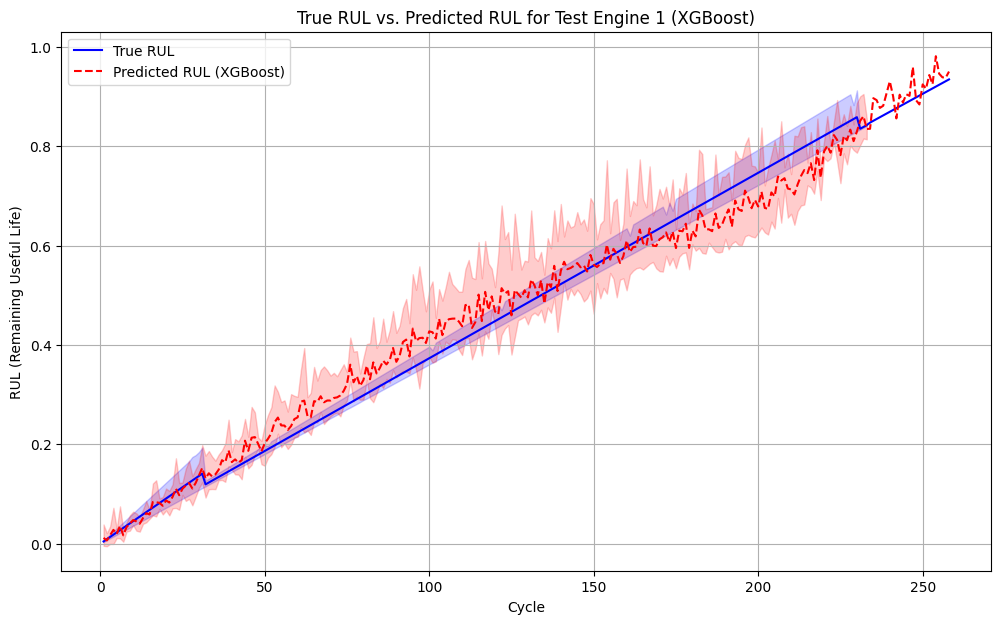

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the combined test data for Engine 1
# The 'engine' column was dropped from X_test_combined but is present in test_data_full_for_correlation
engine_1_test_predictions = test_data_full_for_correlation[test_data_full_for_correlation['engine'] == 1]


plt.figure(figsize=(12, 7))
sns.lineplot(x='cycle', y='RUL', data=engine_1_test_predictions, label='True RUL', color='blue')
sns.lineplot(x='cycle', y='predicted_life_ratio', data=engine_1_test_predictions, label='Predicted RUL (XGBoost)', color='red', linestyle='--')

plt.title('True RUL vs. Predicted RUL for Test Engine 1 (XGBoost)')
plt.xlabel('Cycle')
plt.ylabel('RUL (Remaining Useful Life)')
plt.grid(True)
plt.legend()
plt.show()

# Importantance of features

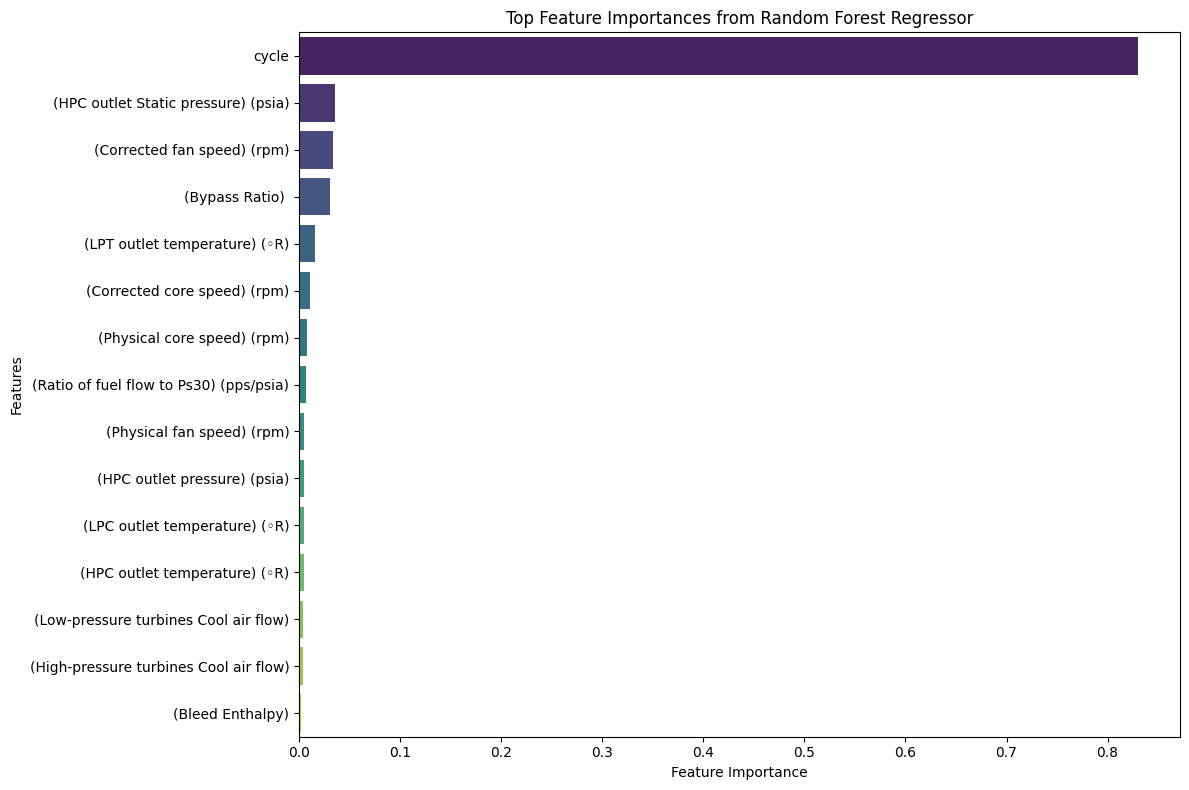

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if 'rf_regressor' not in globals():
    print("Random Forest Regressor not found, initializing and training...")
    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_regressor.fit(X_train_combined, y_train_combined)
    print("Random Forest Regressor training complete!")

feature_importances = rf_regressor.feature_importances_

feature_names = X_train_combined.columns

importance_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top Feature Importances from Random Forest Regressor')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Conclusion

Random Forest Regressor and XGBoost models were trained, which performed almost similarly. The predictions were very well aligned with the true values, which is a good sign. Eventhough Random Forest Regressor performed slightly better the trade off was that it took about 4-5 minutes to train on Google Colab, while XGBoost model was trained much faster.

The implementation of a custom scoring objective function has given these models a more industry oriented prediction capability. Other models can also be trained such as LSTM with a sliding window approach (Taking test data of a group of flights together as input).

Overall, this project has been a good display of how machine learning can help in Predictive Health Monitoring. Afterall, in aviation even the most minute negligence can cost numerous lives.